In [3]:
import pandas as pd
import pyreadr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

In [4]:
fftr = pyreadr.read_r("TEP_FaultFree_Training.RData")
ffData_clean = fftr['fault_free_training']

ftr = pyreadr.read_r("TEP_Faulty_Training.RData")
fData_clean_ = ftr['faulty_training']

fft = pyreadr.read_r("TEP_FaultFree_Testing.RData")
fault_free_test_data = fft['fault_free_testing']

ft = pyreadr.read_r("TEP_Faulty_Testing.RData")
faulty_test_data = ft['faulty_testing']

In [5]:
process_cols = [col for col in ffData_clean.columns if col.startswith('xmeas') or col.startswith('xmv')]

# Handling missing values in fault free data (Training)
ffData_clean[process_cols] = ffData_clean[process_cols].ffill().bfill()

# Hnadling missing values in faulty data (Training)
value = 1 * 60 // 3
fData_clean_ = fData_clean_[fData_clean_['sample'] > value].copy()
fData_clean_[process_cols] = fData_clean_[process_cols].ffill().bfill()

In [6]:
# Scaling the column variables

scaler = StandardScaler()

#Only fitting the faultfree training data
scaler.fit(ffData_clean[process_cols])

ffData_scaled = scaler.transform(ffData_clean[process_cols])

#Tranforming the faulty data on same scaler
fData_scaled = scaler.transform(fData_clean_[process_cols])

#### Note:

We fit StandardScaler on Normal data ONLY because:

1. It establishes the TRUE mean and standard deviation
   of normal plant operation as our reference point

2. If we fit on combined data, fault values would
   DEVIATE the baseline statistics making them
   no longer representative of normal operation

3. This is called DATA LEAKAGE — when information
   from data that shouldn't influence the baseline
   leaks into the preprocessing step

4. Using the SAME scaler on faulty data ensures
   both datasets are in the SAME STATISTICAL space
   making their patterns directly comparable in PCA!

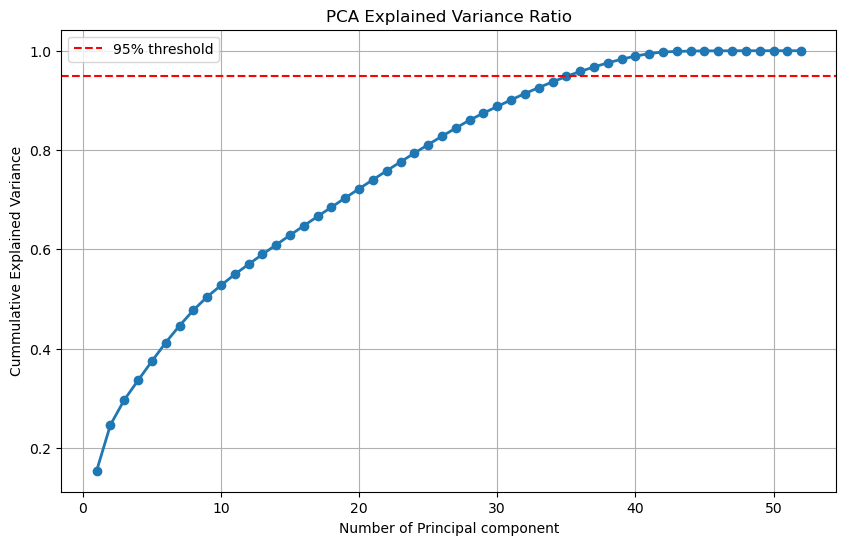

Components needed for 95% variance: 36


In [7]:
from sklearn.decomposition import PCA

pca = PCA()

#Fit PCA on normal training data 
pca.fit(ffData_scaled)

#Plot explained variance ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize = (10,6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o',
    linewidth=2
)

plt.axhline(
    y = 0.95,
    color = 'red',
    linestyle = '--',
    label = '95% threshold'
)

plt.xlabel('Number of Principal component')
plt.ylabel('Cummulative Explained Variance')
plt.title('PCA Explained Variance Ratio')
plt.legend()
plt.grid(True)
plt.show()


# Step 4c: Find optimal number of components
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components}")

In [8]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Exact components for 95% variance: {n_components}")


Exact components for 95% variance: 36


In [9]:
for n in [10, 20, 30, 35, 40]:
    var = cumulative_variance[n-1] * 100
    print(f"Top {n} components explain: {var:.2f}% variance")

Top 10 components explain: 52.74% variance
Top 20 components explain: 72.20% variance
Top 30 components explain: 88.77% variance
Top 35 components explain: 94.83% variance
Top 40 components explain: 98.93% variance


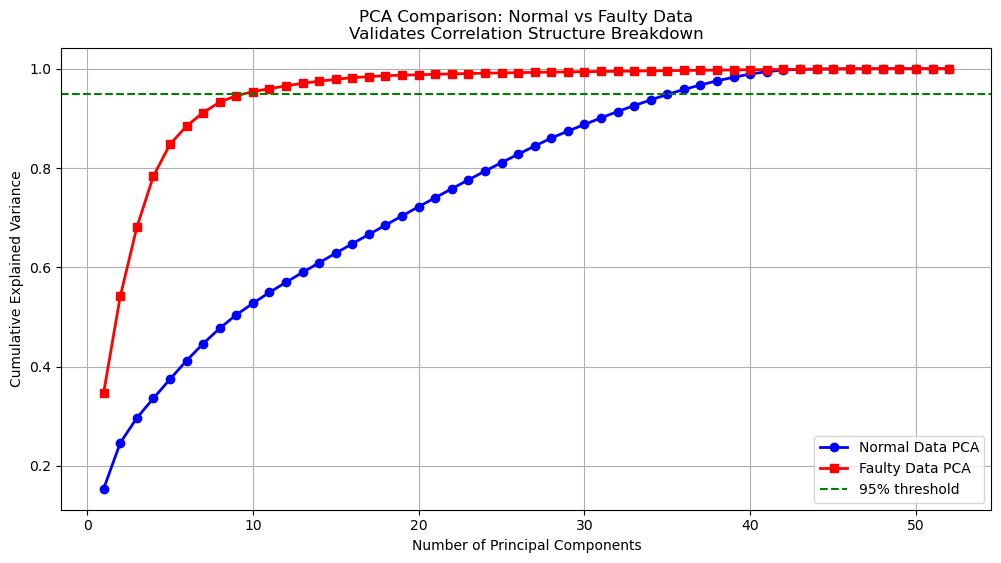

Normal data  ──► 36 components for 95% variance
Faulty data  ──► 10 components for 95% variance

✅ PREDICTION CONFIRMED!
Faulty data needs FEWER components
because fault INCREASES correlations
between sensors (cascade effect)!


In [10]:
## Checking faulty data

pca_faulty = PCA()
pca_faulty.fit(fData_scaled)

cumvar_normal = np.cumsum(pca.explained_variance_ratio_)
cumvar_faulty = np.cumsum(pca_faulty.explained_variance_ratio_)


plt.figure(figsize=(12, 6))
plt.plot(
    range(1, len(cumvar_normal) + 1),
    cumvar_normal,
    marker='o',
    linewidth=2,
    label='Normal Data PCA',
    color='blue'
)

plt.plot(
    range(1, len(cumvar_faulty) + 1),
    cumvar_faulty,
    marker='s',
    linewidth=2,
    label='Faulty Data PCA',
    color='red'
)

plt.axhline(
    y=0.95,
    color='green',
    linestyle='--',
    label='95% threshold'
)


plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Comparison: Normal vs Faulty Data\n'
          'Validates Correlation Structure Breakdown')
plt.legend()
plt.grid(True)
plt.show()

# Compare components needed for 95%
n_normal = np.argmax(cumvar_normal >= 0.95) + 1
n_faulty = np.argmax(cumvar_faulty >= 0.95) + 1
print(f"Normal data  ──► {n_normal} components for 95% variance")
print(f"Faulty data  ──► {n_faulty} components for 95% variance")

if n_faulty < n_normal:
    print(f"\n✅ PREDICTION CONFIRMED!")
    print(f"Faulty data needs FEWER components")
    print(f"because fault INCREASES correlations")
    print(f"between sensors (cascade effect)!")
else:
    print(f"\n Unexpected result — let's investigate!")

## Observation:
- With the fault introduction number of principal component required to capture 95% variance reduces to 10 from 36 PCAs required for capturing normal operation PCAs.
- In chemical plants, if a fault is introduced at a certain point of the plant operation, it's effect are propagated to downstream operation, which would be captured by the sensors installed in the downstream operation.
- This quantitatively proved that faults create massive correlation cascade effects through the plant, and validated PCA as the correct preprocessing choice before I trained a single model!

In [11]:
# Step 4d: Select 36 components (95% of normal variance)
n_components = 36
pca_final = PCA(n_components=n_components)

# Fit on Normal training data ONLY
pca_final.fit(ffData_scaled)

# Transform Normal training data
fftr_pca = pca_final.transform(ffData_scaled)

# Transform Faulty training data using SAME PCA
ftr_pca = pca_final.transform(fData_scaled)

print(f"Normal data after PCA: {fftr_pca.shape}")
print(f"Faulty data after PCA: {ftr_pca.shape}")

Normal data after PCA: (250000, 36)
Faulty data after PCA: (4800000, 36)


In [12]:
pc_cols = [f'PC{i+1}' for i in range(n_components)]

fftr_df = pd.DataFrame(fftr_pca,columns = pc_cols)
fftr_df['label'] = 0

ftr_df = pd.DataFrame(ftr_pca, columns = pc_cols)
ftr_df['label'] = fData_clean_['faultNumber'].values

print("Normal data label distribution:")
print(fftr_df['label'].value_counts())
print("\nFaulty data label distribution:")
print(ftr_df['label'].value_counts())

Normal data label distribution:
label
0    250000
Name: count, dtype: int64

Faulty data label distribution:
label
1     240000
2     240000
19    240000
18    240000
17    240000
16    240000
15    240000
14    240000
13    240000
12    240000
11    240000
10    240000
9     240000
8     240000
7     240000
6     240000
5     240000
4     240000
3     240000
20    240000
Name: count, dtype: int64


In [13]:
#import joblib

# Save scaler and PCA objects
#joblib.dump(scaler, 'scaler.pkl')
#joblib.dump(pca_final, 'pca_normal_baseline.pkl')

# Transform Testing datasets
# Fault Free Testing
fftest_data = fault_free_test_data.copy()
fftest_data[process_cols] = fftest_data[process_cols].ffill().bfill()

#Scale using SAME scaler (faultfree data - Testing)
fftest_scaled = scaler.transform(fftest_data[process_cols])

#Transform using same scaler (Faultfree data - Testing)
fftest_pca = pca_final.transform(fftest_scaled)


In [14]:
#############################################

#Transforming faulty testing datasets
# Faulty testing
ftest_data = faulty_test_data.copy()

value = 8 * 60 // 3  # 160 samples for testing!
ftest_data_clean = ftest_data[ftest_data['sample'] > value].copy()

ftest_data_clean[process_cols] = ftest_data_clean[process_cols].ffill().bfill()

#Scale faulty test using same scaler
ftest_scaled = scaler.transform(ftest_data_clean[process_cols])

#Transform using same PCA
ftest_pca = pca_final.transform(ftest_scaled)


In [15]:
# Save all transformed datasets
np.save('fftr_pca.npy', fftr_pca)   # Normal Training
np.save('ftr_pca.npy', ftr_pca)     # Faulty Training
np.save('fft_pca.npy', fftest_pca)  # Normal Testing
np.save('ft_pca.npy', ftest_pca)    # Faulty Testing

# Extract labels to variables first to avoid repetitive DataFrame slicing
ftr_labels = fData_clean_['faultNumber'].values
ft_labels = ftest_data_clean['faultNumber'].values

# Save labels for faulty datasets
np.save('ftr_labels.npy', ftr_labels) # Faulty Training labels
np.save('ft_labels.npy', ft_labels)   # Faulty Testing labels

# Verify shapes using RAM variables (DO NOT use np.load here)
print("Verification — shapes must match row by row:")
print(f"Faulty Training PCA:    {ftr_pca.shape}")
print(f"Faulty Training labels: {ftr_labels.shape}")
print(f"Faulty Testing PCA:     {ftest_pca.shape}")
print(f"Faulty Testing labels:  {ft_labels.shape}")


Verification — shapes must match row by row:
Faulty Training PCA:    (4800000, 36)
Faulty Training labels: (4800000,)
Faulty Testing PCA:     (8000000, 36)
Faulty Testing labels:  (8000000,)


In [16]:
np.save('fftr_scaled.npy', ffData_scaled)    # Normal Training scaled
np.save('ftr_scaled.npy', fData_scaled)      # Faulty Training scaled
np.save('fftest_scaled.npy', fftest_scaled)  # Normal Testing scaled
np.save('ftest_scaled.npy', ftest_scaled)    # Faulty Testing scaled


print("Scaled data saved successfully!")
print(f"Normal Training scaled:  {ffData_scaled.shape}")
print(f"Faulty Training scaled:  {fData_scaled.shape}")
print(f"Normal Testing scaled:   {fftest_scaled.shape}")
print(f"Faulty Testing scaled:   {ftest_scaled.shape}")

Scaled data saved successfully!
Normal Training scaled:  (250000, 52)
Faulty Training scaled:  (4800000, 52)
Normal Testing scaled:   (480000, 52)
Faulty Testing scaled:   (8000000, 52)
